## 1. Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 2. Load Data & Clean Column Names

In [33]:
df = pd.read_csv('../data/diabetes.csv')

df.columns = df.columns.str.strip()
df.rename(columns={
    'preg': 'Pregnancies',
    'plas': 'Glucose',
    'pres': 'BloodPressure',
    'Skin': 'SkinThickness',
    'test': 'Insulin',
    'mass': 'BMI',
    'pedi': 'DiabetesPedigree',
    'age': 'Age',
    'class': 'Outcome'
}, inplace=True)

print(df.columns.tolist())
df.head(10)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Initial Inspection

In [34]:
df.shape

(768, 9)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Exploratory Data Analysis

### Class balance

In [37]:
df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

### Distributions

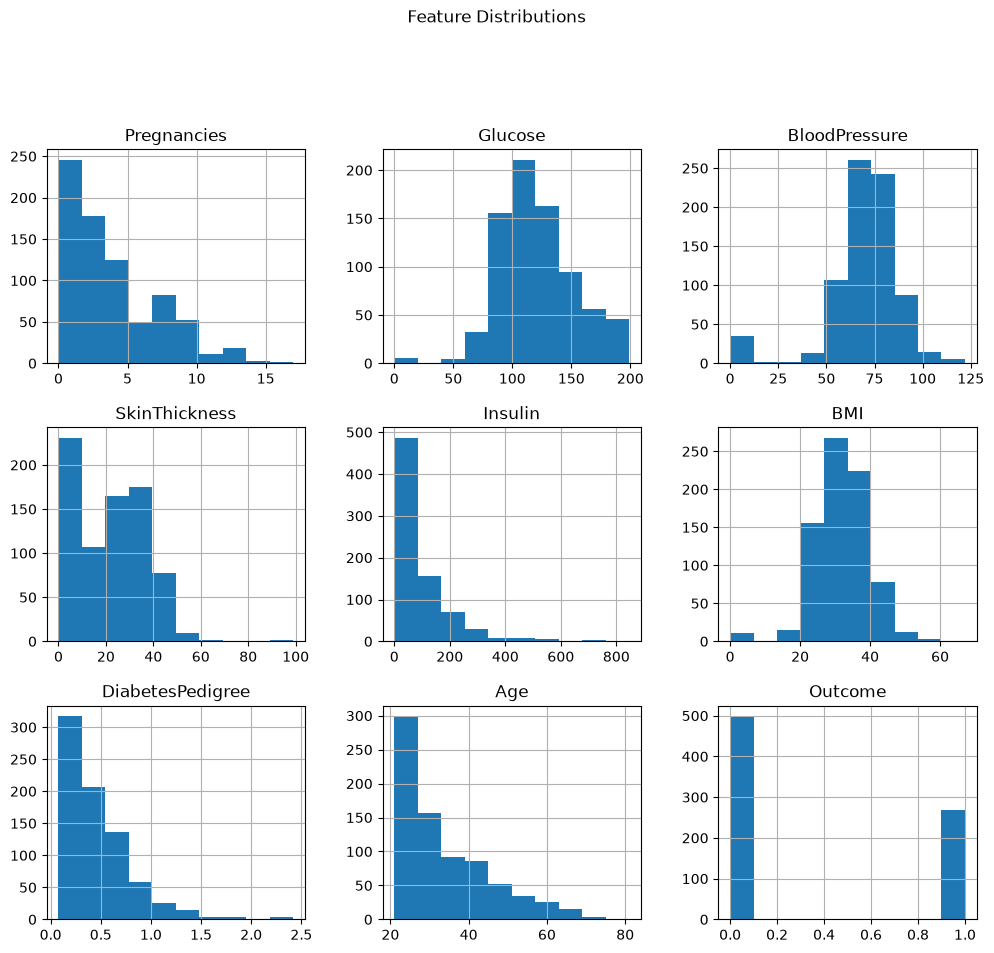

In [38]:
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

### Outlier check (boxplots)

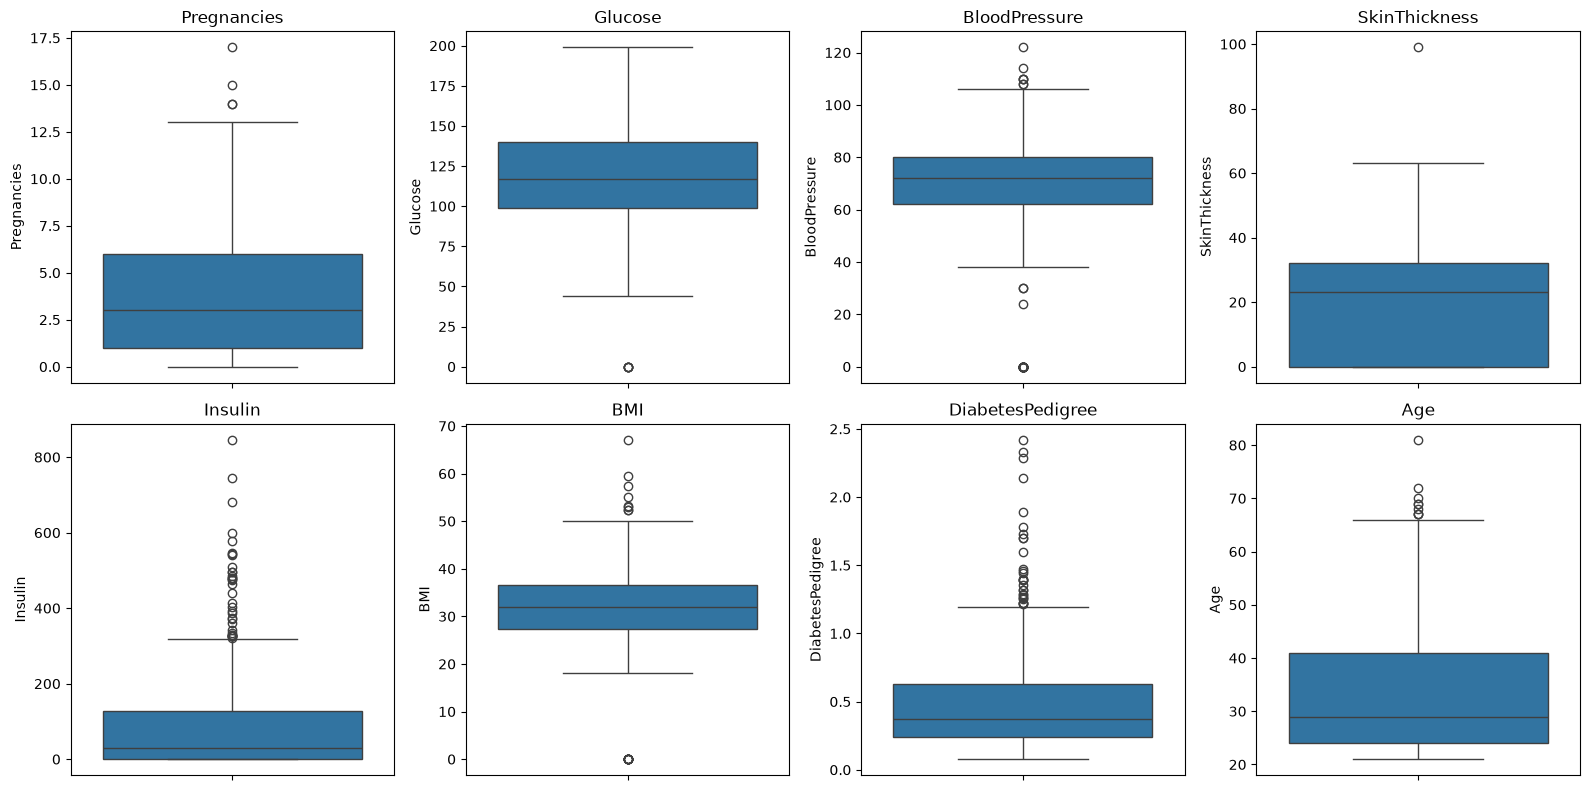

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols_to_plot = df.columns[:-1]  # everything except Outcome

for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=df[col], ax=axes[i // 4][i % 4])
    axes[i // 4][i % 4].set_title(col)

plt.tight_layout()
plt.show()

### Correlation heatmap

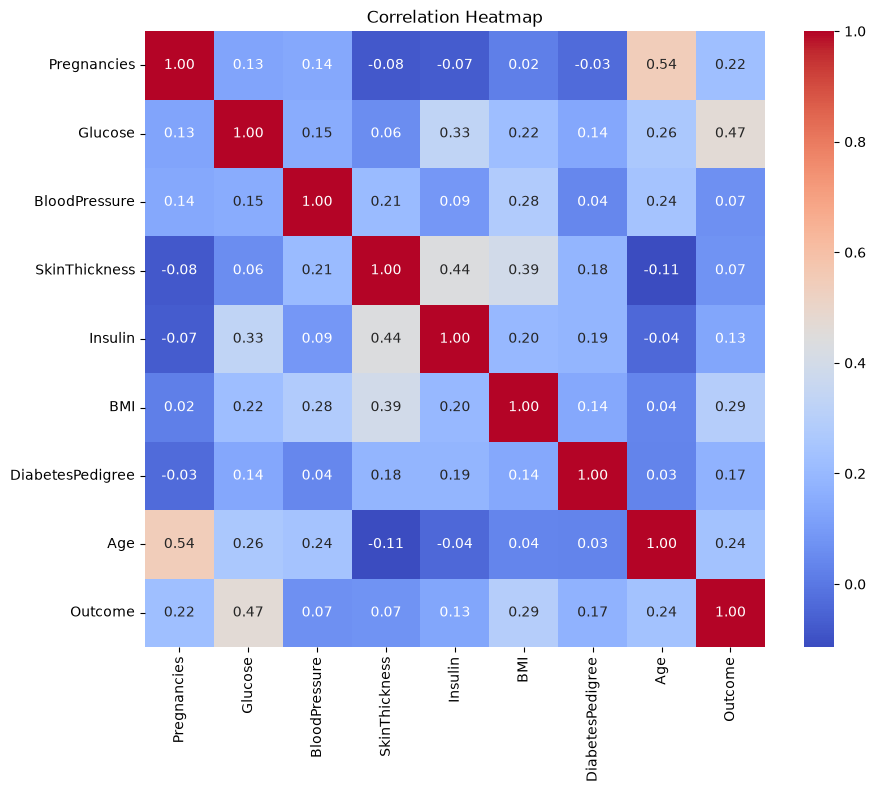

In [40]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## 5. Data Cleaning

### Duplicates

In [41]:
dupes = df.duplicated().sum()
print("Duplicate rows:", dupes)
df = df.drop_duplicates()

Duplicate rows: 0


### Disguised missing values (zeros in medically-impossible columns)

In [42]:
cols_with_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero-count per column (before):")
print((df[cols_with_missing] == 0).sum())

df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)

print("\nMissing values BEFORE imputation:")
print(df.isnull().sum())

Zero-count per column (before):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values BEFORE imputation:
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


In [43]:
for col in cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

print("Missing values AFTER imputation:")
print(df.isnull().sum())

Missing values AFTER imputation:
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64


## 6. Prepare Data for Machine Learning

### Split features and target

In [44]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

### Scale features

In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train/test split (70/30, stratified)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)

X_train: (537, 8)  y_train: (537,)
X_test: (231, 8)  y_test: (231,)


### Readiness checks

In [47]:
print("Missing values in X_train:", pd.DataFrame(X_train).isnull().sum().sum())
print("Missing values in y_train:", pd.Series(y_train).isnull().sum())
print("All numeric:", np.issubdtype(X_train.dtype, np.number))
print("Row counts match:", X_train.shape[0] == y_train.shape[0], X_test.shape[0] == y_test.shape[0])
print("Column counts match:", X_train.shape[1] == X_test.shape[1])
print("\nClass balance - train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass balance - test:")
print(pd.Series(y_test).value_counts(normalize=True))
print("\nScaled means (should be ~0):", X_train.mean(axis=0).round(2))
print("Scaled stds (should be ~1):", X_train.std(axis=0).round(2))

Missing values in X_train: 0
Missing values in y_train: 0
All numeric: True
Row counts match: True True
Column counts match: True

Class balance - train:
Outcome
0    0.651769
1    0.348231
Name: proportion, dtype: float64

Class balance - test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

Scaled means (should be ~0): [ 0.01 -0.   -0.01 -0.03 -0.03  0.02  0.03  0.03]
Scaled stds (should be ~1): [0.99 0.98 1.01 0.94 0.92 0.98 1.01 1.  ]
